# Projeto II EDP\Modelagem

---------------

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import itertools

## Parte 1: Problema Direto

In [4]:
D = 0.1                       # difusão
Q = 50.0                      # taxa da fonte
xs, ys = 40.0, 28.0           # posição da fonte
Lx, Ly = 200.0, 50.0          # tamanho do domínio
T = 500

# --- grade ---
dx = 1.0
dy = 1.0
dt = 0.1

nx = int(Lx/dx) + 1
ny = int(Ly/dy) + 1
nt = int(T/dt) + 1

x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
t = np.linspace(0, T, nt)

u = np.zeros((ny, nx))        

u_M1 = np.zeros(nt)
u_M2 = np.zeros(nt)
u_M3 = np.zeros(nt)

# velocidade parabólica
v = 4*y*(50-y)/50**2          # só depende de y

# índice da fonte (delta aproximada)
ix = np.argmin(abs(x - xs))
iy = np.argmin(abs(y - ys))


In [5]:
tol = 1e-3
tol_hit_count = 0

for n in tqdm(range(nt)):   

    #n = int(n)
    u_M1[n] = u[15,150]
    u_M2[n] = u[25,150]
    u_M3[n] = u[35,150]
    
    un = u.copy()

    for j in range(1, ny-1):
        for i in range(1, nx-1):

            adv = -v[j] * (un[j, i] - un[j, i-1]) / dx

            diff = D * (
                (un[j, i+1] - 2*un[j, i] + un[j, i-1]) / dx**2 +
                (un[j+1, i] - 2*un[j, i] + un[j-1, i]) / dy**2
            )

            src = Q/(dx*dy) if (i == ix and j == iy) else 0

            
            u[j, i] = un[j, i] + dt*(adv + diff + src)

    u[:, 0] = 0
    u[:, -1] = u[:, -2]
    u[0, :] = u[1, :]
    u[-1, :] = u[-2, :]

    if np.max(np.abs(u - un)) < tol and tol_hit_count == 0:
        n_steady_state = n
        tol_hit_count += 1
        #break
print("steady state alcançado no tempo(s) ", n_steady_state*dt)

  0%|          | 0/5001 [00:00<?, ?it/s]

steady state alcançado no tempo(s)  205.9


--------------

### Plot das Figuras

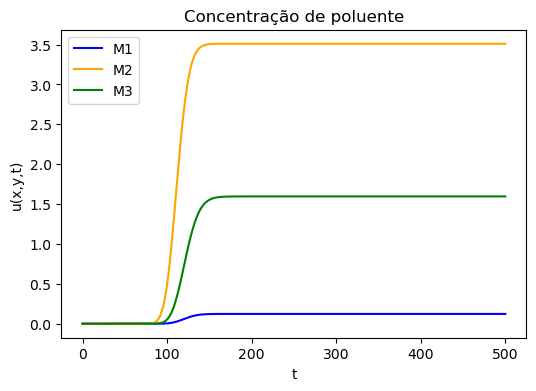

In [6]:
fig,ax = plt.subplots(figsize=(6,4))

tmax = int(T / dt)

ax.plot(t[:tmax],u_M1[:tmax],label="M1",color="blue")
ax.plot(t[:tmax],u_M2[:tmax],label="M2",color="orange")
ax.plot(t[:tmax],u_M3[:tmax],label="M3",color="green")

ax.set_xlabel('t')
ax.set_ylabel('u(x,y,t)')
ax.set_title('Concentração de poluente')
plt.legend()
plt.show()

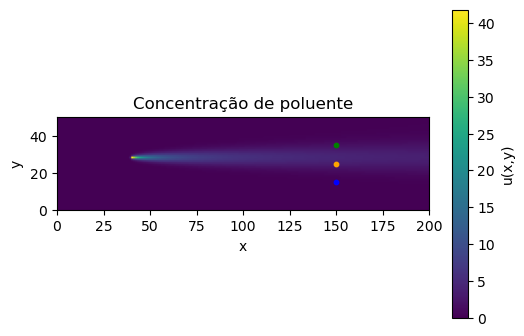

In [7]:
fig, ax = plt.subplots(figsize=(6,4))
im = ax.imshow(u, origin='lower',extent=[x.min(), x.max(), y.min(), y.max()])
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('u(x,y)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Concentração de poluente')

ax.scatter(150,15,label="M1",color="blue",s=10)
ax.scatter(150,25,label="M2",color="orange",s=10)
ax.scatter(150,35,label="M3",color="green",s=10)

plt.show()



In [8]:
print("Concentração no Sensor M2 no regime assíntótico permanente foi de " ,u_M2[n_steady_state])

Concentração no Sensor M2 no regime assíntótico permanente foi de  3.5109030968369477


-------------------

## Parte 2: Problema Inverso 

Ta incompleto, vou adicionar os gráficos mais tarde

In [2]:
import pandas as pd

In [14]:
path = "sensors_desafio.csv"
df = pd.read_csv(path)

df

,time,sensor_M1,sensor_M2,sensor_M3
0,1.066667,0.000000,0.000000,0.000000
1,2.133333,0.000000,0.000000,0.000000
2,3.200000,0.000000,0.000000,0.000000
3,4.266667,0.000000,0.000000,0.000000
4,5.333333,0.000000,0.000000,0.000000
...,...,...,...,...
464,496.000000,0.007277,2.158983,6.127059
465,497.066667,0.007519,1.915420,5.722561
466,498.133333,0.006851,2.094785,6.089317
467,499.200000,0.007127,1.996862,5.249133


In [5]:


def u_num(xs,ys,Q):
    t_per_data = 2
    n_data_points = len(df.index)
    nt = n_data_points * t_per_data
    
    D = 0.1
    Lx, Ly = 200.0, 50.0

    dx = 1.0
    dy = 1.0
    T = df.time.values[-1]
    dt = (T/(nt))
    
    nx = int(Lx/dx) + 1
    ny = int(Ly/dy) + 1
    
    x = np.linspace(0, Lx, nx)
    y = np.linspace(0, Ly, ny)
    
    u = np.zeros((ny, nx)) 
    
    
    u_M1 = np.zeros(n_data_points)
    u_M2 = np.zeros(n_data_points)
    u_M3 = np.zeros(n_data_points)
    
    v = 4*y*(50-y)/50**2          
    
    ix = np.argmin(abs(x - xs))
    iy = np.argmin(abs(y - ys))

    time_bar = tqdm(range(nt), 
                   desc="Time steps em u_num", 
                   position=1,  
                   leave=False,
                   bar_format='{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt}')
    
    
    for n in time_bar:
    #for n in range(nt):
    
        # print(n % t_per_data)
        # print(int(n / t_per_data))
        # print("-----------")
        
        if n % t_per_data == 0:
            m = int(n / t_per_data)
            u_M1[m] = u[15,150]
            u_M2[m] = u[25,150]
            u_M3[m] = u[35,150]
        else:
            pass
        
        #time_bar.set_description(f"Time step {n+1}/{nt} | M1={u_M1[n]:.2f}")
        # time_bar.set_description(f"Time step {n+1}/{nt} | M1")
        # time_bar.set_postfix({
        #     "M2": f"{u_M2[n]:.2f}",
        #     "M3": f"{u_M3[n]:.2f}"
        # })
        
        un = u.copy()
    
        for j in range(1, ny-1):
            for i in range(1, nx-1):
    
                adv = -v[j] * (un[j, i] - un[j, i-1]) / dx
    
                diff = D * (
                    (un[j, i+1] - 2*un[j, i] + un[j, i-1]) / dx**2 +
                    (un[j+1, i] - 2*un[j, i] + un[j-1, i]) / dy**2
                )
    
                src = Q/(dx*dy) if (i == ix and j == iy) else 0
    
                
                u[j, i] = un[j, i] + dt*(adv + diff + src)
    
        u[:, 0] = 0
        u[:, -1] = u[:, -2]
        u[0, :] = u[1, :]
        u[-1, :] = u[-2, :]
        


    return [u_M1,u_M2,u_M3]
       

In [6]:
def L(xs,ys,Q):
    nt = len(df)
    u_num_arr = u_num(xs,ys,Q)
    # print(u_num_arr[0][-40:]) DEBUG
    # print(df.sensor_M1[-40:]) DEBUG
    L_M1 = (u_num_arr[0] - df.sensor_M1)**2
    L_M2 = (u_num_arr[1] - df.sensor_M2)**2
    L_M3 = (u_num_arr[2] - df.sensor_M3)**2
    
    return np.sum(L_M1 + L_M2 + L_M3) / (3*nt)
    


---------------

### Grid Search

In [8]:
total_grid_size = 150
param_grid_size = int(total_grid_size **(1/3))

xs_grid = np.linspace(37,43,param_grid_size)
ys_grid = np.linspace(26,30,param_grid_size)
Q_grid = np.linspace(25,75,param_grid_size)

total_grid = itertools.product(xs_grid,ys_grid,Q_grid)


L_min = 1e100
for p in total_grid:
    xs,ys,Q = p
    Loss = L(xs,ys,Q)
    if Loss < L_min:
        L_min = Loss
    else:
        pass
    print(L_min)

Time steps em u_num:   0%|          | 0/938

8.316072792034937


Time steps em u_num:   0%|          | 0/938

8.113666011515535


Time steps em u_num:   0%|          | 0/938

...

2.0850699582317795


Time steps em u_num:   0%|          | 0/938

2.0850699582317795


Time steps em u_num:   0%|          | 0/938

2.0477435897529412


In [9]:
print("A Loss encontrada foi de ", L_min)

A Loss encontrada foi de  2.0477435897529412


In [17]:
total_grid = [ p for p in itertools.product(xs_grid,ys_grid,Q_grid)]
opt_param = total_grid[25]

app_M1, app_M2, app_M3 = u_num(opt_param[0],opt_param[1],opt_param[2])
actual_M1, actual_M2, actual_M3 = df.sensor_M1.values, df.sensor_M2.values, df.sensor_M3.values 

Time steps em u_num:   0%|          | 0/938

----------------

### Gráfico

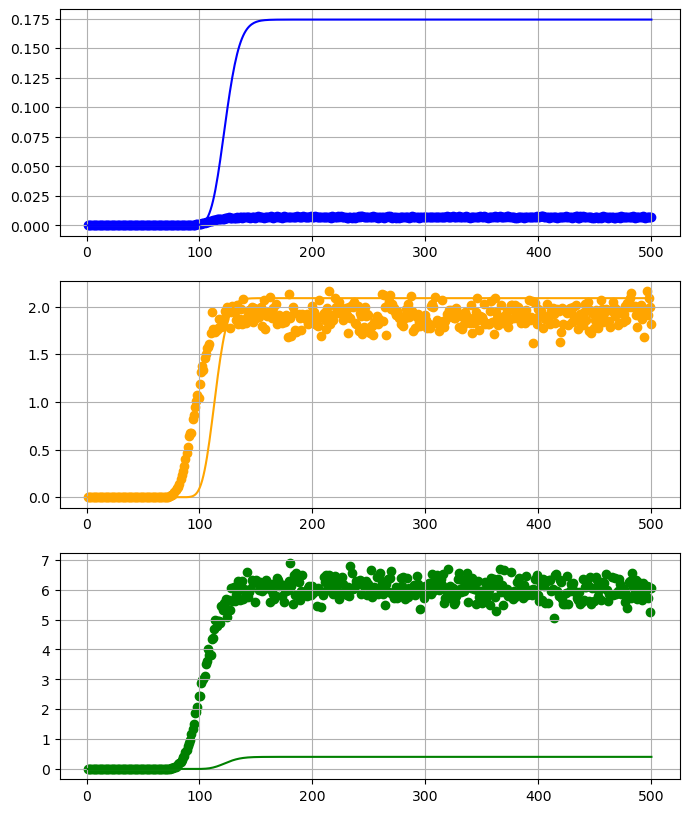

In [26]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10))

time = df.time.values

ax1.scatter(x=time,y=actual_M1,color="blue",label = "Solução Encontrada (M1)")
ax1.plot(time,app_M1,color="blue",label = "Solução Aproximada (M1)")

ax2.scatter(x=time,y=actual_M2,color="orange",label = "Solução Encontrada (M2)")
ax2.plot(time,app_M2,color="orange",label = "Solução Aproximada (M2)")

ax3.scatter(x=time,y=actual_M3,color="green",label = "Solução Encontrada (M3)")
ax3.plot(time,app_M3,color="green",label = "Solução Aproximada (M3)")

ax1.grid()
ax2.grid()
ax3.grid()

-----------

### Tentativa de Descida de Gradiente (não convergiu)

In [83]:
eps = np.random.normal(0,1,size=3)
p0 = np.array([40,28,50])
# p1 = p0 + eps # CHAT GPT

p_prev = p0
# p_curr = p1 # CHAT GPT

gamma = 0.5
n_iter = 50
loss_tol = 1e-1
min_dp = 0.05

iter_bar = tqdm(range(n_iter), 
                desc="Steps of Gradient Descent", 
                position=0,
                leave=True,
                bar_format='{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt}')

for iteration in iter_bar:
    # bacht_size = len(df.index) 
    dp = np.array([1,1,1]) * 1e-4
       
    L_prev = L(p_prev[0],p_prev[1],p_prev[2])
    print("A perda é " , L_prev)
    if L_prev <= loss_tol:
        iter_bar.set_description("Convergiu : Loss less then " ,loss_tol)
        break

    # Lx =  (L(p_curr[0],p_prev[1],p_prev[2]) - L_prev) / dp[0]
    # Ly =  (L(p_prev[0],p_curr[1],p_prev[2]) - L_prev) / dp[1]
    # LQ =  (L(p_prev[0],p_prev[1],p_curr[2]) - L_prev) / dp[2]
    
    # Lx = (L(p_prev[0] + dp[0], p_prev[1], p_prev[2]) - L_prev) / dp[0] # CHAT GPT
    # Ly = (L(p_prev[0], p_prev[1] + dp[1], p_prev[2]) - L_prev) / dp[1] # CHAT GPT
    # LQ = (L(p_prev[0], p_prev[1], p_prev[2] + dp[2]) - L_prev) / dp[2] # CHAT GPT

    Lx = (L(p_prev[0] + dp[0], p_prev[1], p_prev[2]) - L(p_prev[0] - dp[0], p_prev[1], p_prev[2])) / (2*dp[0]) # CHAT GPT

    Ly = (L(p_prev[0], p_prev[1] + dp[1], p_prev[2]) - L(p_prev[0], p_prev[1] - dp[1], p_prev[2])) / (2*dp[1]) # CHAT GPT

    LQ = (L(p_prev[0], p_prev[1], p_prev[2] + dp[2]) - L(p_prev[0], p_prev[1], p_prev[2] - dp[2])) / (2*dp[2]) # CHAT GPT
    
    L_grad = np.array([Lx,Ly,LQ])
    
    #p_next = p_curr - gamma * L_grad
    
    g_norm = np.linalg.norm(L_grad) # CHAT GPT
    if g_norm > 0: # CHAT GPT
        p_prev = p_prev - gamma * L_grad / g_norm # CHAT GPT
    
    p_prev = p_next.copy()
    
    # p_prev = p_curr.copy()
    # p_curr = p_next
    iter_bar.set_postfix({"L": f"{np.linalg.norm(L_grad):.1e}"})
    
    
    
    
    
    # if np.linalg.norm(L_grad) <= grad_tol:
    #     batch_bar.set_description("Batch optimization - CONVERGED")
    #     break
    
   # if np.linalg.norm(L_grad) <= grad_tol:
   #     break

    

Steps of Gradient Descent:   0%|          | 0/50

Time steps em u_num:   0%|          | 0/938

A perda é  5.933300604129078


Time steps em u_num:   0%|          | 0/938

Time steps em u_num:   0%|          | 0/938

...

Time steps em u_num:   0%|          | 0/938

Time steps em u_num:   0%|          | 0/938

Time steps em u_num:   0%|          | 0/938

Time steps em u_num:   0%|          | 0/938

Time steps em u_num:   0%|          | 0/938

In [74]:
p_test = p_curr
L(p_test[0],p_test[1],p_test[2])

Rodar com tol = 0.1 !!!


Time steps em u_num:   0%|          | 0/938

np.float64(5.951789524963367)